<a href="https://colab.research.google.com/github/ricardo-gmarques/estagio/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise da RAIS 2023 – Setor de TI em São Paulo

Este relatório analisa dados da RAIS 2023 com foco nos profissionais de Tecnologia da Informação no estado de São Paulo.

In [3]:
df = pd.read_csv('/content/raisfinal-ricardo-gomes_000000000000.csv')
df.head()

,id_municipio,sexo,idade,grau_instrucao_apos_2005,raca_cor,cbo_2002,cnae_2,valor_remuneracao_media,quantidade_horas_contratadas
0,3550308,1,62,9,2,212410,6120,15095.53,44
1,3509502,1,61,9,2,142505,6120,18994.12,44
2,3550308,1,62,9,2,317105,6202,15657.19,40
3,3550308,1,60,9,2,212215,6201,11264.56,40
4,3509502,1,60,9,2,212405,7210,18015.64,99


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363042 entries, 0 to 363041
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_municipio                  363042 non-null  int64  
 1   sexo                          363042 non-null  int64  
 2   idade                         363042 non-null  int64  
 3   grau_instrucao_apos_2005      363042 non-null  int64  
 4   raca_cor                      363042 non-null  int64  
 5   cbo_2002                      363042 non-null  int64  
 6   cnae_2                        363042 non-null  int64  
 7   valor_remuneracao_media       363042 non-null  float64
 8   quantidade_horas_contratadas  363042 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 24.9 MB


In [6]:
df.describe()

,id_municipio,sexo,idade,grau_instrucao_apos_2005,raca_cor,cbo_2002,cnae_2,valor_remuneracao_media,quantidade_horas_contratadas
count,3.630420e+05,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000
mean,3.538504e+06,1.217518,35.016574,8.848759,3.733271,223163.358702,6182.625762,9809.056773,46.637138
std,1.787445e+04,0.412558,9.677982,0.585817,2.645201,50453.755655,1474.322617,8720.969277,16.919502
min,3.500105e+06,1.000000,18.000000,2.000000,1.000000,123605.000000,111.000000,1.000000,1.000000
25%,3.524709e+06,1.000000,27.000000,9.000000,2.000000,212405.000000,6201.000000,3863.487500,40.000000
50%,3.550308e+06,1.000000,34.000000,9.000000,2.000000,212405.000000,6204.000000,7452.215000,40.000000
75%,3.550308e+06,1.000000,41.000000,9.000000,6.000000,212420.000000,6611.000000,13122.342500,44.000000
max,3.557303e+06,2.000000,82.000000,11.000000,9.000000,317210.000000,9900.000000,193156.160000,99.000000


In [8]:
%run /content/LimpezaDados-v2(2022).py

###################################

Separação de dados RAIS - Filtrando para Sorocaba


Processando...

Total de itens: 0

0.0 segundos

###################################


In [63]:
import pandas as pd

print("###################################\n")
print("Limpeza e preparação dos dados RAIS 2023\n")

# 📂 Carregar arquivo
df = pd.read_csv('/content/raisfinal-ricardo-gomes_000000000000.csv')

# 🔍 Conferência inicial
print("Linhas iniciais:", len(df))

# 🧹 (Reforço de limpeza - segurança)
df = df[df['valor_remuneracao_media'] > 0]
df = df[df['quantidade_horas_contratadas'] > 0]
df = df[df['idade'].between(18, 90)]
df = df[df['grau_instrucao_apos_2005'] != 1]

# 🔄 Renomear colunas (padrão do relatório)
df = df.rename(columns={
    "sexo": "Sexo Trabalhador",
    "valor_remuneracao_media": "Vl Remun Média Nom",
    "grau_instrucao_apos_2005": "Escolaridade após 2005",
    "idade": "Idade",
    "cbo_2002": "CBO Ocupação 2002",
    "raca_cor": "Raça Cor",
    "id_municipio": "Município",
    "quantidade_horas_contratadas": "Qtd Hora Contr"
})

# garantir que são string
df['Sexo Trabalhador'] = df['Sexo Trabalhador'].astype(str)

df['Sexo Trabalhador'] = df['Sexo Trabalhador'].map({
    '1': 'Masculino',
    '2': 'Feminino'
})

# escolaridade também (já aproveita)

df['Escolaridade após 2005'] = df['Escolaridade após 2005'].astype(str)


df['Escolaridade após 2005'] = df['Escolaridade após 2005'].map({
    '1': 'Analfabeto',
    '2': 'Até 5ª incompleta',
    '3': '5ª completa Fundamental',
    '4': '6ª a 9ª Fundamental',
    '5': 'Fundamental completo',
    '6': 'Médio incompleto',
    '7': 'Médio completo',
    '8': 'Superior incompleto',
    '9': 'Superior completo',
    '10': 'Mestrado',
    '11': 'Doutorado'

})

# 🧠 Criar variável nova (salário por hora)
df['Horas Mensais'] = df['Qtd Hora Contr'] * 4.33
df['Salario Hora'] = df['Vl Remun Média Nom'] / df['Horas Mensais']

# 📊 Conferência final
print("Linhas após limpeza:", len(df))
print(df.head())

# 💾 Salvar base tratada
df.to_csv('/content/dados_tratados.csv', index=False)

print("\nArquivo salvo como: dados_tratados.csv")
print("\n###################################")

###################################

Limpeza e preparação dos dados RAIS 2023

Linhas iniciais: 363042
Linhas após limpeza: 363042
   Município Sexo Trabalhador  Idade Escolaridade após 2005  Raça Cor  \
0    3550308        Masculino     62      Superior completo         2   
1    3509502        Masculino     61      Superior completo         2   
2    3550308        Masculino     62      Superior completo         2   
3    3550308        Masculino     60      Superior completo         2   
4    3509502        Masculino     60      Superior completo         2   

   CBO Ocupação 2002  cnae_2  Vl Remun Média Nom  Qtd Hora Contr  \
0             212410    6120            15095.53              44   
1             142505    6120            18994.12              44   
2             317105    6202            15657.19              40   
3             212215    6201            11264.56              40   
4             212405    7210            18015.64              99   

   Horas Mensais  Sal

In [31]:
df[['Vl Remun Média Nom', 'Salario Hora', 'Idade', 'Qtd Hora Contr']].describe()

,Vl Remun Média Nom,Salario Hora,Idade,Qtd Hora Contr
count,363042.000000,363042.000000,363042.000000,363042.000000
mean,9809.056773,50.945492,35.016574,46.637138
std,8720.969277,74.514517,9.677982,16.919502
min,1.000000,0.230947,18.000000,1.000000
25%,3863.487500,20.291506,27.000000,40.000000
50%,7452.215000,37.793731,34.000000,40.000000
75%,13122.342500,66.974596,41.000000,44.000000
max,193156.160000,22753.078522,82.000000,99.000000


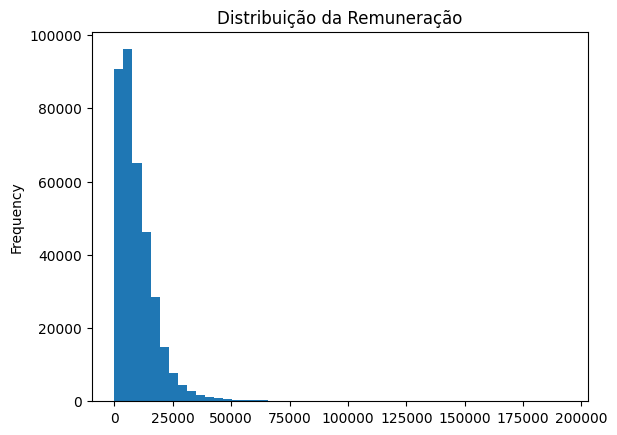

In [32]:
import matplotlib.pyplot as plt

df['Vl Remun Média Nom'].plot(kind='hist', bins=50)
plt.title('Distribuição da Remuneração')
plt.show()

In [33]:
df['Sexo Trabalhador'].value_counts()

,count
Sexo Trabalhador,
Masculino,284074
Feminino,78968


In [34]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].mean()


,Vl Remun Média Nom
Sexo Trabalhador,
Feminino,8820.661638
Masculino,10083.814713


In [35]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].median()

,Vl Remun Média Nom
Sexo Trabalhador,
Feminino,6543.96
Masculino,7733.28


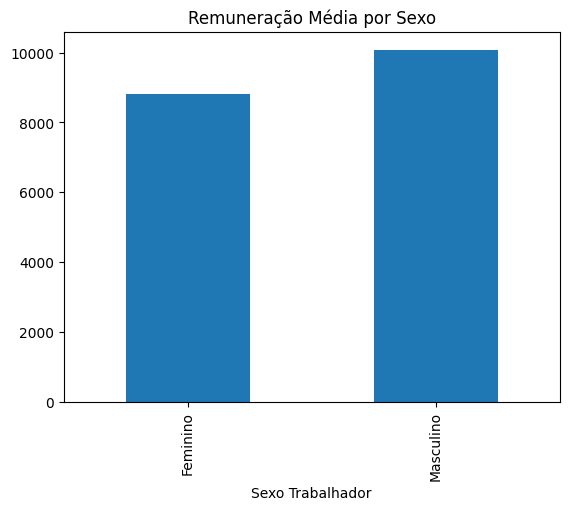

In [36]:
df.groupby('Sexo Trabalhador')['Vl Remun Média Nom'].mean().plot(kind='bar')
plt.title('Remuneração Média por Sexo')
plt.show()

In [66]:
ordem = [

    'Até 5ª incompleta',
    '5ª completa Fundamental',
    '6ª a 9ª Fundamental',
    'Fundamental completo',
    'Médio incompleto',
    'Médio completo',
    'Superior incompleto',
    'Superior completo',
    'Mestrado',
    'Doutorado'
]

df['Escolaridade após 2005'] = pd.Categorical(
    df['Escolaridade após 2005'],
    categories=ordem,
    ordered=True
)

In [64]:
df['Escolaridade após 2005'].value_counts().sort_index()

,count
Escolaridade após 2005,
5ª completa Fundamental,21
6ª a 9ª Fundamental,69
Até 5ª incompleta,22
Doutorado,1340
Fundamental completo,421
Mestrado,5909
Médio completo,22644
Médio incompleto,809
Superior completo,318335


In [65]:
df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().sort_index()

,Vl Remun Média Nom
Escolaridade após 2005,
5ª completa Fundamental,4104.114762
6ª a 9ª Fundamental,3950.839710
Até 5ª incompleta,4778.459545
Doutorado,18585.541627
Fundamental completo,3693.776461
Mestrado,18921.254260
Médio completo,3607.734538
Médio incompleto,3233.529011
Superior completo,10290.785792


In [67]:
df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].median().sort_index()

/tmp/ipykernel_1667/1374599943.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].median().sort_index()


,Vl Remun Média Nom
Escolaridade após 2005,
Até 5ª incompleta,3564.580
5ª completa Fundamental,3518.190
6ª a 9ª Fundamental,3001.860
Fundamental completo,2879.590
Médio incompleto,2363.030
Médio completo,2607.570
Superior incompleto,3274.070
Superior completo,8120.970
Mestrado,15342.170


/tmp/ipykernel_1667/2775709446.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().plot(kind='bar')


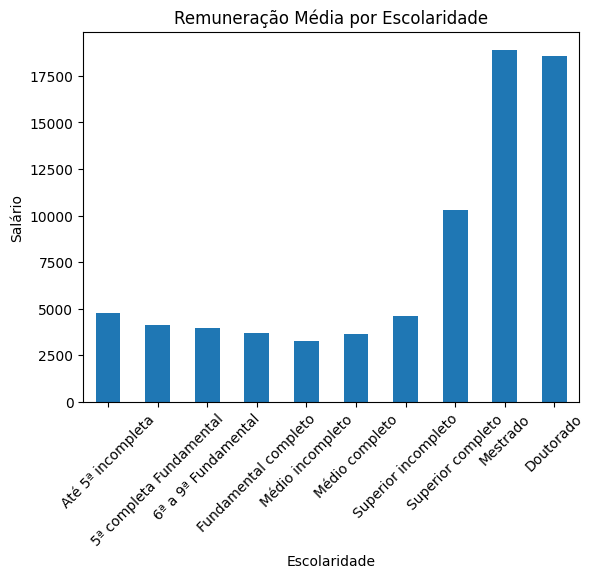

In [68]:
import matplotlib.pyplot as plt

df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean().plot(kind='bar')

plt.title('Remuneração Média por Escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Salário')
plt.xticks(rotation=45)
plt.show()

In [69]:
df.groupby('Escolaridade após 2005')['Salario Hora'].mean().sort_index()

/tmp/ipykernel_1667/1513063778.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Escolaridade após 2005')['Salario Hora'].mean().sort_index()


,Salario Hora
Escolaridade após 2005,
Até 5ª incompleta,26.289852
5ª completa Fundamental,21.605120
6ª a 9ª Fundamental,21.561130
Fundamental completo,20.461865
Médio incompleto,17.532366
Médio completo,20.156821
Superior incompleto,25.994639
Superior completo,53.319784
Mestrado,94.779149


In [70]:
media = df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean()

variacao = media.pct_change() * 100

resultado = pd.DataFrame({
    'Salário Médio': media,
    'Variação (%)': variacao
})

resultado.round(2)

/tmp/ipykernel_1667/2410468628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media = df.groupby('Escolaridade após 2005')['Vl Remun Média Nom'].mean()


,Salário Médio,Variação (%)
Escolaridade após 2005,,
Até 5ª incompleta,4778.46,NaN
5ª completa Fundamental,4104.11,-14.11
6ª a 9ª Fundamental,3950.84,-3.73
Fundamental completo,3693.78,-6.51
Médio incompleto,3233.53,-12.46
Médio completo,3607.73,11.57
Superior incompleto,4612.79,27.86
Superior completo,10290.79,123.09
Mestrado,18921.25,83.87
